# Anomaly Detection and Unsupervised Learning

**You can never collect data on a failure that has not happened yet — so instead of learning what failure looks like, you learn what *normal* looks like, and watch for anything that isn't.**

*Companion notebook to Chapter 56 — Anomaly Detection and Unsupervised Learning.*

Supervised learning requires labeled examples of failures. In structural health monitoring, failures are rare — that is the whole point of designing safe structures — so labeled failure data is almost never available in sufficient quantity for supervised training. *Anomaly detection* sidesteps this problem by learning only from normal data: it builds a model of what the structure looks and sounds like when healthy, then flags departures from that model as anomalies worth investigating.

Two complementary approaches are demonstrated here. **PCA reconstruction error** compresses the multi-channel feature vector into a low-dimensional representation of normal variation, then measures how far each new sample lies from that normal subspace. Samples that cannot be reconstructed accurately — because their pattern does not match anything seen during normal operation — are flagged as anomalies. This approach is interpretable: the reconstruction error has physical meaning as "how abnormal is this sample compared to the training distribution."

**Isolation Forest** takes a fundamentally different approach, exploiting the geometric intuition that anomalies are rare and structurally different from normal points, and therefore easier to isolate in feature space. It builds an ensemble of random decision trees that recursively partition the feature space; anomalies require fewer partitions to isolate and receive correspondingly extreme anomaly scores. The key tuning parameter is the contamination fraction; because we fit the forest on the healthy baseline alone, it sets the share of that baseline the model will flag — in effect, the tolerated false-alarm rate — and thereby fixes the decision threshold.

**This notebook demonstrates:**
1. Anomaly detection on a four-channel strain feature dataset using PCA reconstruction error (3σ threshold) and Isolation Forest, comparing detection rate and false alarms — with all preprocessing statistics learned from the healthy baseline alone, so no anomaly information leaks into the model.

In [1]:
# Colab setup: uncomment to install dependencies when running in Google Colab
# !pip install numpy matplotlib scikit-learn

import pathlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — PCA Reconstruction Error and Isolation Forest: Detecting Load-Path Changes

The simulation creates 1000 normal operating samples (zero-mean, unit covariance in four feature dimensions) and 30 anomalous samples whose mean is shifted to [2, 2, −2, −2] and whose spread is wider than normal — representing a load-path change that elevates two feature channels while suppressing two others, as might occur if a structural member buckles or a joint fails. The challenge is to detect these 30 anomalies without prior knowledge of what they look like.

Everything downstream depends on one discipline the chapter insists on: the preprocessing statistics must come from the healthy baseline alone. The `StandardScaler` is therefore fit on the 1000 normal samples only, and the *same* centering and scaling are then applied to every sample. Fitting the scaler on the combined set — baseline plus anomalies — would let the anomalies leak into the mean and standard deviation, which is exactly the mistake Chapter 56 warns against ("recompute the statistics from each new batch, and the anomaly scores are no longer well-defined"). PCA is likewise fit on the standardized normal samples only, retaining the two principal components that explain most of the normal-operation variance. New samples (including the anomalies) are projected onto this two-component subspace and reconstructed; the mean squared reconstruction error is the anomaly score.

The 3σ threshold is set from the normal training data. If reconstruction error were Gaussian, a 3σ limit would flag only about 0.3% of normal samples — but reconstruction error is a sum of squared residuals, non-negative and right-skewed, so the realized false-alarm rate is typically higher than that Gaussian rule of thumb suggests. That gap is precisely why the chapter's threshold-setting section prefers an empirical quantile (the 99th or 99.9th percentile of the baseline scores) over a *k*·σ rule. We keep the transparent 3σ rule here and simply report the false alarms it actually produces.

The left panel shows the PCA score space: the normal cloud is compact and centered; the anomalies scatter far from the normal distribution, making their separation visually clear. The right panel shows the reconstruction error as a time series: the normal samples produce low error throughout, while the anomalies stand out above the threshold. The comparison with Isolation Forest quantifies the detection performance of both approaches on identical data — showing whether the two methods agree on which samples are anomalous.

PCA 3σ threshold = 1.9113
Detected 19/30 anomalies, 18 false alarms from 1000 normal samples
Isolation Forest: detected 25/30, 30 false alarms


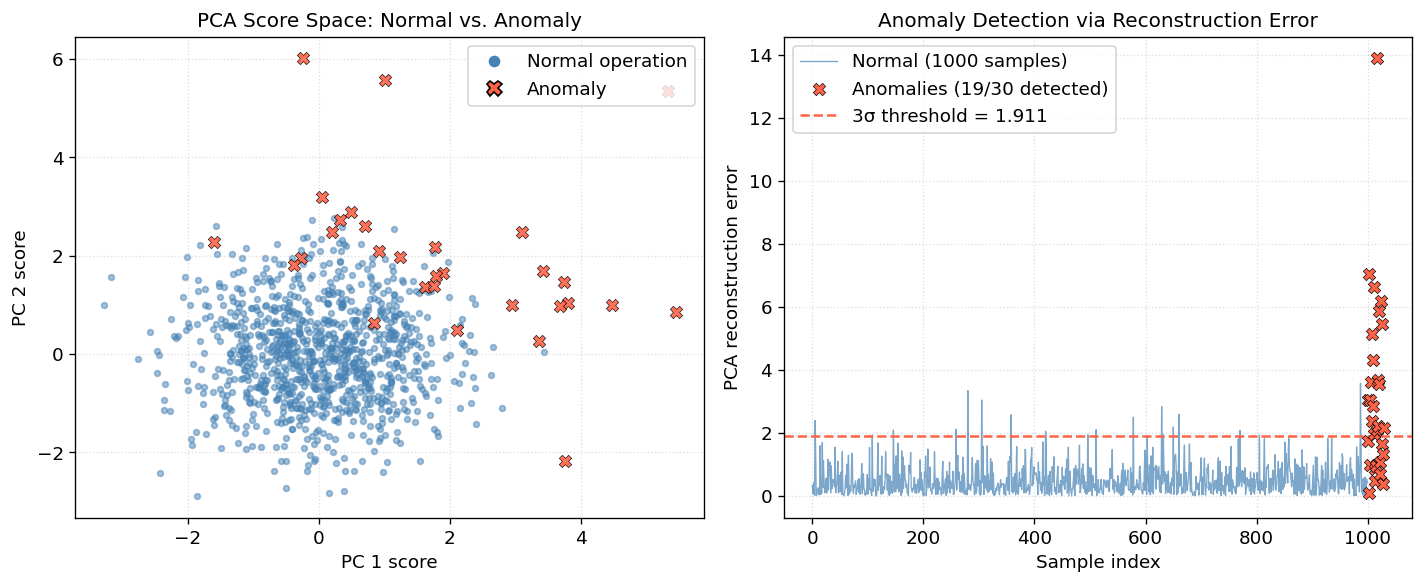

Figure saved to ..\src\media\ch56\fig56_2_anomaly_detection.png


In [2]:
# --- Reproducibility and experiment configuration -------------------------
SEED = 10                        # seeds every source of randomness below
N_NORMAL = 1000                  # healthy-baseline samples
N_ANOM = 30                      # injected anomalies (a load-path change)
N_FEATURES = 4                   # strain feature channels
ANOMALY_MEAN = [2, 2, -2, -2]    # mean shift of the anomalous samples
ANOMALY_COV_SCALE = 3            # anomalies are more dispersed than normal
N_COMPONENTS = 2                 # PCA components retained for the normal subspace
SIGMA_MULTIPLIER = 3             # 3-sigma control limit on reconstruction error
CONTAMINATION = N_ANOM / (N_NORMAL + N_ANOM)  # expected outlier fraction for the forest

OUT_DIR = pathlib.Path('../src/media/ch56')
OUT_DIR.mkdir(parents=True, exist_ok=True)


def reconstruction_error(model, X):
    """Return the per-sample mean squared PCA reconstruction error.

    Each row of ``X`` is projected onto the retained principal-component
    subspace and reconstructed; the mean squared error between a sample and
    its reconstruction is its anomaly score. Large values mean the sample
    lies far from the normal subspace the model learned during fitting.
    """
    X_recon = model.inverse_transform(model.transform(X))
    return np.mean((X - X_recon) ** 2, axis=1)


# --- Synthetic four-channel strain data -----------------------------------
np.random.seed(SEED)
X_normal = np.random.multivariate_normal(
    np.zeros(N_FEATURES), np.eye(N_FEATURES), N_NORMAL)
X_anom = np.random.multivariate_normal(
    ANOMALY_MEAN, np.eye(N_FEATURES) * ANOMALY_COV_SCALE, N_ANOM)
X_all = np.vstack([X_normal, X_anom])
labels = np.array(['OK'] * N_NORMAL + ['Anomaly'] * N_ANOM)

# Fit the scaler on the HEALTHY BASELINE ONLY, then apply the same transform
# to every sample. Fitting on the full set would let the anomalies leak into
# the centering/scaling statistics -- exactly what the chapter warns against.
scaler = StandardScaler().fit(X_normal)
Xs = scaler.transform(X_all)
Xs_normal = Xs[:N_NORMAL]

# --- PCA reconstruction error ---------------------------------------------
pca = PCA(n_components=N_COMPONENTS).fit(Xs_normal)
recon_err = reconstruction_error(pca, Xs)

baseline_err = recon_err[:N_NORMAL]
threshold = baseline_err.mean() + SIGMA_MULTIPLIER * baseline_err.std()
detected = np.sum(recon_err[N_NORMAL:] > threshold)
false_alarms = np.sum(baseline_err > threshold)
print(f"PCA {SIGMA_MULTIPLIER}σ threshold = {threshold:.4f}")
print(f"Detected {detected}/{N_ANOM} anomalies, "
      f"{false_alarms} false alarms from {N_NORMAL} normal samples")

# --- Isolation Forest (fit on the healthy baseline only) ------------------
iso = IsolationForest(contamination=CONTAMINATION, random_state=SEED).fit(Xs_normal)
iso_pred = iso.predict(Xs)   # -1 = anomaly, +1 = normal
iso_detected = np.sum(iso_pred[N_NORMAL:] == -1)
iso_fa = np.sum(iso_pred[:N_NORMAL] == -1)
print(f"Isolation Forest: detected {iso_detected}/{N_ANOM}, {iso_fa} false alarms")

# --- Figure ---------------------------------------------------------------
idx = np.arange(len(X_all))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: PCA score space. A distinct MARKER per class (not colour alone)
# keeps the two groups separable in grayscale / B&W print.
ok = labels == 'OK'
axes[0].scatter(Xs[ok, 0], Xs[ok, 1], marker='o', s=12, alpha=0.5,
                color='steelblue', label='Normal operation')
axes[0].scatter(Xs[~ok, 0], Xs[~ok, 1], marker='X', s=55, alpha=0.9,
                color='tomato', edgecolor='black', linewidths=0.4, label='Anomaly')
axes[0].set_title('PCA Score Space: Normal vs. Anomaly')
axes[0].set_xlabel('PC 1 score')
axes[0].set_ylabel('PC 2 score')
axes[0].grid(True, linestyle=':', alpha=0.4)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Normal operation'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='tomato',
           markeredgecolor='black', markersize=9, label='Anomaly')]
axes[0].legend(handles=legend_elements)

# Right panel: reconstruction error timeline
axes[1].plot(idx[:N_NORMAL], recon_err[:N_NORMAL], color='steelblue', lw=0.8,
             alpha=0.7, label=f'Normal ({N_NORMAL} samples)')
# Same X marker as the left panel: shape, not color, names the anomalies.
axes[1].scatter(idx[N_NORMAL:], recon_err[N_NORMAL:], color='tomato', marker='X',
                s=55, edgecolor='black', linewidths=0.4, zorder=5,
                label=f'Anomalies ({detected}/{N_ANOM} detected)')
axes[1].axhline(threshold, color='tomato', lw=1.5, linestyle='--',
                label=f'{SIGMA_MULTIPLIER}σ threshold = {threshold:.3f}')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('PCA reconstruction error')
axes[1].set_title('Anomaly Detection via Reconstruction Error')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig56_2_anomaly_detection.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"Figure saved to {OUT_DIR / 'fig56_2_anomaly_detection.png'}")

---
## Where to take this next

The demonstration above is a foundation. Three concrete extensions turn it into something closer to a deployable monitor:

1. **Validate the threshold out of sample.** Right now the 3σ limit is set and its false-alarm rate is measured on the *same* baseline. Follow the chapter's step-4 procedure instead: hold out a block of normal data that is separated by time, season, or operating condition, set the threshold on the training baseline only, and measure the realized false-alarm rate on the untouched holdout. Compare it against the design target — an in-sample estimate almost always looks better than the field will.

2. **Replace the 3σ rule with an empirical quantile.** Because reconstruction error is right-skewed, a *k*·σ limit and the 99th/99.9th-percentile threshold (Eq. 56 threshold-setting section) can disagree markedly. Compute both on the baseline scores, plot the score histogram, and see how the two thresholds trade detection rate against false alarms.

3. **Add temporal and nonlinear structure.** Layer a CUSUM statistic (Eq. 56.2) on top of the per-sample reconstruction error to catch a slow drift whose individual samples never trip the point threshold — the fatigue-progression case the chapter highlights. Then swap the linear PCA model for a small autoencoder (Eq. 56.1) and check whether the nonlinear normal manifold separates the same anomalies with a lower false-alarm rate.